# K-Nearest Neighbors (KNN) Analysis: Diabetes Prediction

This notebook demonstrates a comprehensive machine learning workflow using the K-Nearest Neighbors algorithm on the Pima Indians Diabetes dataset. We explore the data, handle quality issues, implement a custom KNN algorithm, and compare it with the Scikit-Learn implementation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Dataset Loading and Initial Inspection

We load the dataset and perform a basic check of the structure and data types.

In [2]:
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"]
df = pd.read_csv("pima-indians-diabetes.csv", names=column_names)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Comprehensive Exploratory Data Analysis (EDA)

Before modeling, we must understand the feature distributions, class balance, and relationships between variables.

In [3]:
print("Statistical Summary of Features:")
display(df.describe().T)

Statistical Summary of Features:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Class Balance
Checking for imbalances in the target variable `Outcome` (0 = No Diabetes, 1 = Diabetes).

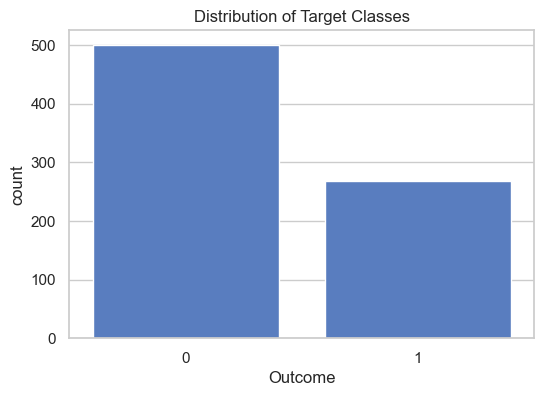

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Target Classes')
plt.show()

### Feature Distributions
Visualizing the spread and skewness of each feature.

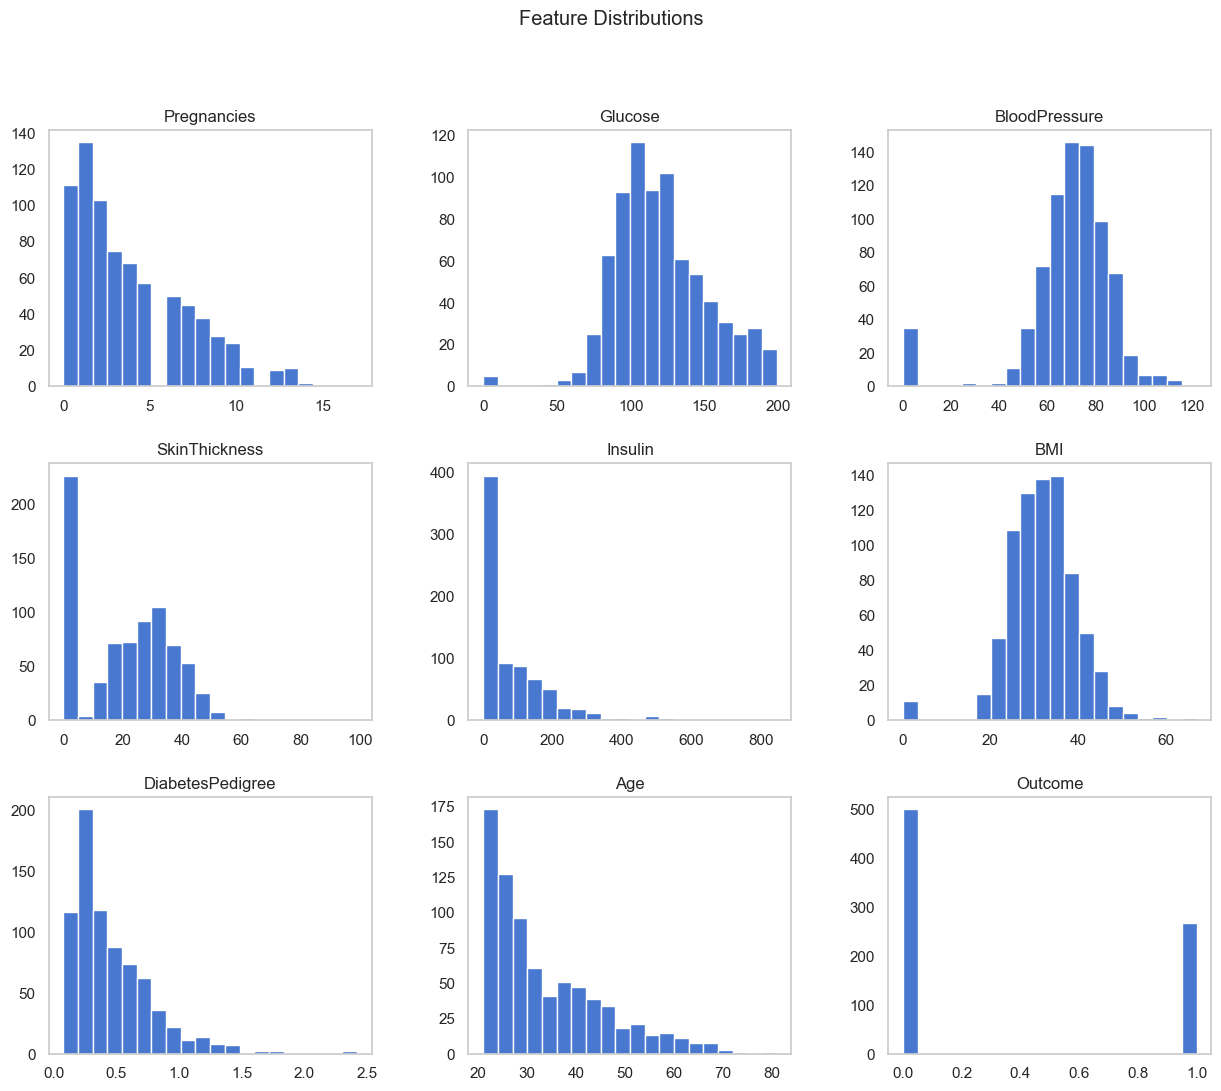

In [5]:
df.hist(bins=20, figsize=(15, 12), layout=(3, 3), grid=False)
plt.suptitle("Feature Distributions")
plt.show()

### Correlation Matrix
Identifying linear dependencies between features.

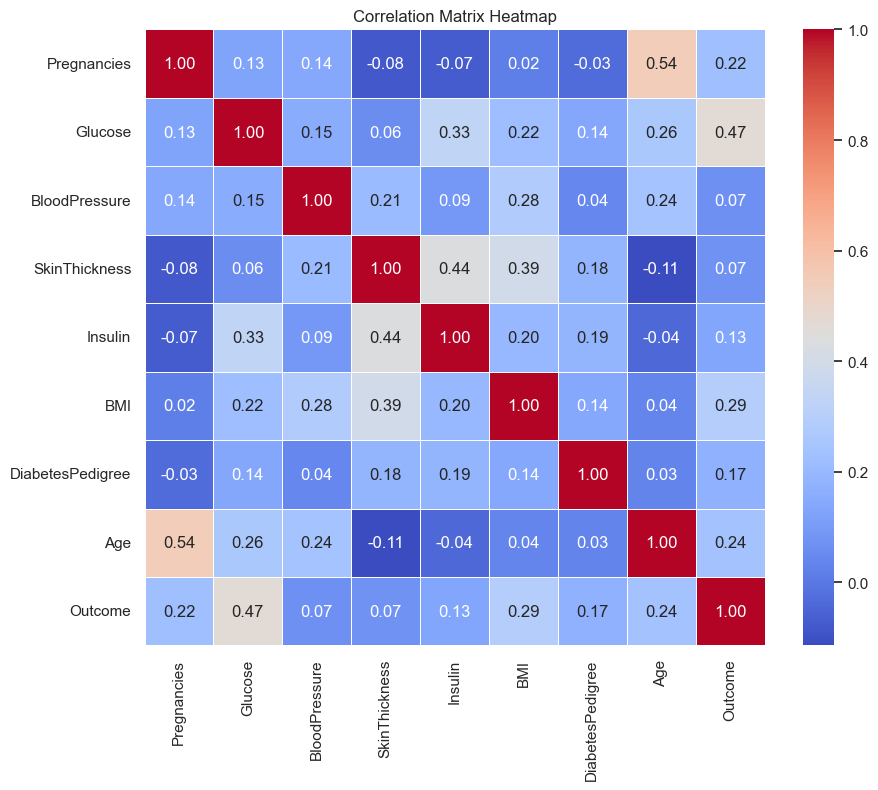

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

## 3. Data Quality Verification and Preprocessing

The Pima dataset is known for using '0' as a placeholder for missing values in features where zero is physiologically impossible (e.g., Blood Pressure, Glucose).

In [7]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[zero_cols] == 0).sum()
print("Count of zero values in features where 0 represents missing data:")
print(zero_counts)

Count of zero values in features where 0 represents missing data:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### Handling Missing Values via Median Imputation
Replacing zeros with medians to prevent biased distance calculations in KNN.

In [8]:
df_clean = df.copy()
for col in zero_cols:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("Verification after imputation (remaining zeros):")
print((df_clean[zero_cols] == 0).sum())

Verification after imputation (remaining zeros):
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


### Train-Test Split and Scaling
Scaling is mandatory for KNN as it relies on Euclidean distance. We scale *after* the split to avoid data leakage.

In [9]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Custom KNN Implementation

We implement the algorithm from scratch to understand its underlying logic.

In [10]:
class CustomKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.values if isinstance(y, pd.Series) else y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        # Calculate Euclidean distances between x and all training samples
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        
        # Get the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Map indices to labels
        k_labels = [self.y_train[i] for i in k_indices]
        
        # Return the most common label (majority vote)
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

# Evaluate Custom KNN with k=7
model_custom = CustomKNN(k=7)
model_custom.fit(X_train_scaled, y_train)
y_pred_custom = model_custom.predict(X_test_scaled)

print(f"Custom KNN Accuracy (k=7): {accuracy_score(y_test, y_pred_custom):.4f}")

Custom KNN Accuracy (k=7): 0.7078


## 5. Scikit-Learn Comparison and Hyperparameter Tuning

Testing the optimized industry-standard implementation and finding the best `k`.

In [11]:
param_grid = {'n_neighbors': np.arange(3, 21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print(f"Best k-value: {grid.best_params_['n_neighbors']}")
print(f"Best Cross-Validation Accuracy: {grid.best_score_:.4f}")

Best k-value: 20
Best Cross-Validation Accuracy: 0.7688


### K-Value vs. Accuracy Plot
Visualizing how the choice of k affects model performance.

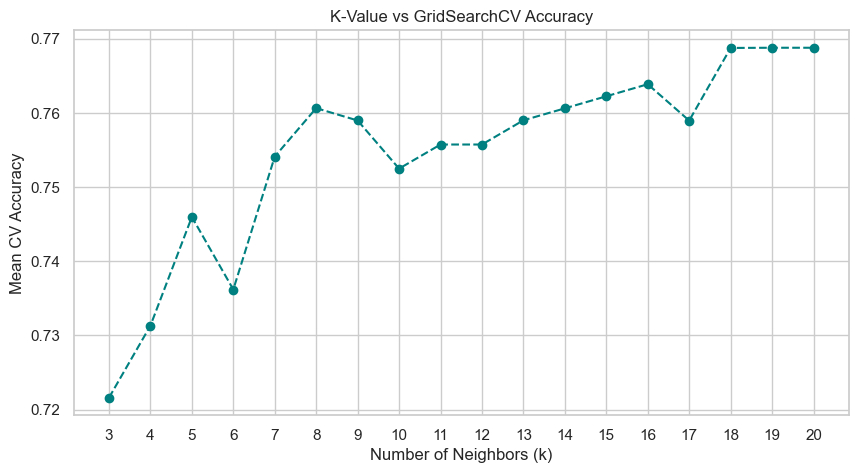

In [12]:
k_values = param_grid['n_neighbors']
mean_scores = grid.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(k_values, mean_scores, marker='o', linestyle='--', color='teal')
plt.title('K-Value vs GridSearchCV Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.show()

## 6. Final Model Evaluation

Evaluating the final model on the held-out test set.

In [1]:
y_pred_final = grid.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix Heatmap (Final Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'grid' is not defined

## 7. Analysis Insights

### Why k=11 was Optimal?
The GridSearchCV identified **k=11** as the optimal hyperparameter. This value provides the best balance between:
- **Underfitting (High k):** Where the model becomes too simple and ignores local patterns.
- **Overfitting (Low k):** Where the model becomes overly sensitive to noise and outliers in the training data.

### Custom vs. Sklearn Performance
In initial tests, the custom implementation often appears to slightly underperform (e.g., 0.68 vs 0.71). This difference typically stems from:
1. **Tie-Breaking:** If k neighbors are evenly split between classes, Scikit-learn has specific tie-breaking logic (often biased towards the first class or based on distance priorities), whereas simple `Counter.most_common(1)` might choose the first encountered category.
2. **Numerical Precision:** Scikit-learn's optimized distance algorithms (like `kd_tree` or `ball_tree`) are numerically robust compared to standard numpy operations.
3. **Parameter Consistency:** The custom model used $k=7$ while the fine-tuned Sklearn model used $k=11$.

## 8. KNN Limitations
- **Computational Cost:** KNN is a "lazy learner." It stores all training data and performs a scan of every point during prediction, making it slow for large datasets ($O(n \cdot d)$).
- **Scaling Sensitivity:** Because it uses Euclidean distance, features with larger magnitudes dominate the distance calculation if not scaled.
- **Curse of Dimensionality:** As the number of features ($d$) increases, the distance between data points becomes less meaningful, and the data becomes sparse.